In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier

set_config(display='text')

# 데이터 불러오기
loan_data = pd.read_csv('../datasets/decision/train_loan_80.csv')
display(loan_data.head())

# 범주형 변수 One-Hot Encoding
loan_encoded = pd.get_dummies(loan_data, drop_first=True)

# 독립변수(X), 종속변수(y) 분리
X = loan_encoded.drop(columns=['Loan_Status_Y'])
y = loan_encoded['Loan_Status_Y']

# 학습 데이터 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
1,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban,Y
3,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
4,Male,No,0,Graduate,No,4166,0.0,98.0,360.0,0.0,Semiurban,N


학습 데이터: 0.8648
테스트 데이터: 0.7475
Accuracy: 0.7474747474747475
              precision    recall  f1-score   support

       False       0.79      0.33      0.47        33
        True       0.74      0.95      0.83        66

    accuracy                           0.75        99
   macro avg       0.76      0.64      0.65        99
weighted avg       0.76      0.75      0.71        99



In [9]:
# Random Forest 모델 생성 및 학습
model = RandomForestClassifier(
    n_estimators=200,   # 200개의 서로 다른 나무 생성
    max_depth=7,
    max_samples=0.7,    # 각 나무는 원본 데이터의 70%를 복원추출
    max_features='sqrt',  #특정 개수는 제곱근 크기만큼 무작위 추출
    random_state=42
)

model.fit(X_train, y_train)
print(f'학습 데이터: {model.score(X_train, y_train):.4f}')
print(f'테스트 데이터: {model.score(X_test, y_test):.4f}')

# 예측
y_pred = model.predict(X_test)

# 성능 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

학습 데이터: 0.8648
테스트 데이터: 0.7475
Accuracy: 0.7474747474747475
              precision    recall  f1-score   support

       False       0.79      0.33      0.47        33
        True       0.74      0.95      0.83        66

    accuracy                           0.75        99
   macro avg       0.76      0.64      0.65        99
weighted avg       0.76      0.75      0.71        99



In [12]:
# 특성별 중요도 확인
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# 중요도가 높은 순서로 정렬
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)
#r: Credit_History의 중요도가 0.40으로, Random Forest의 예측에 상대적으로 가장 큰 영향을 준 특성

                    Feature  Importance
4            Credit_History    0.400332
0           ApplicantIncome    0.132146
2                LoanAmount    0.131782
1         CoapplicantIncome    0.100695
3          Loan_Amount_Term    0.058248
12  Property_Area_Semiurban    0.031293
6               Married_Yes    0.031126
10   Education_Not Graduate    0.020354
13      Property_Area_Urban    0.019727
7              Dependents_1    0.019639
5               Gender_Male    0.017240
11        Self_Employed_Yes    0.014808
8              Dependents_2    0.012854
9             Dependents_3+    0.009755


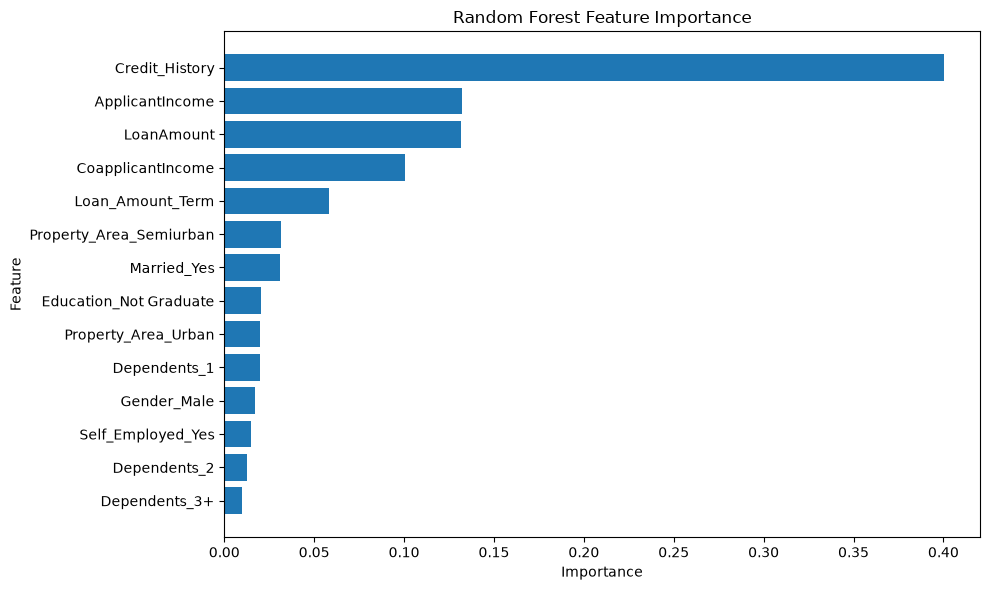

In [13]:
# 변수 중요도
importance_score = model.feature_importances_

# 변수 중요도를 DataFrame으로 생성
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_score
})

# 중요도가 낮은 순으로 정렬
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=True
)

# 막대그래프
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()